# Polymarket Free-API Exploration

**Goal:** demonstrate end-to-end what is retrievable from Polymarket's free APIs
(Gamma, CLOB, Data), how to preprocess it, and which signals the v2 spec relies
on are actually visible. This is **not** the production loader — it is a
sandbox to validate assumptions before writing the real ingestor.

**Endpoints used (all unauthenticated):**
- `https://gamma-api.polymarket.com/markets`
- `https://gamma-api.polymarket.com/events/{id}`
- `https://clob.polymarket.com/book`
- `https://clob.polymarket.com/prices-history`
- `https://data-api.polymarket.com/trades`
- `https://data-api.polymarket.com/holders`

**Pitfalls covered:**
1. Stringified-JSON array fields in Gamma.
2. **Timestamp units differ by endpoint** (ms / s / ISO).
3. negRisk families are linked by **event id**, not `negRiskRequestID`.
4. Yes and No `prices-history` series do **not** share timestamps; must resample.
5. `/holders` returns nested-by-token, not flat.

Conventions:
- All timestamps canonicalised to a `ts_utc` column (`datetime64[ns, UTC]`).
- All notionals in USDC.

## 0. Setup

In [1]:
import json
import time
from typing import Any

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (11, 4)

GAMMA = "https://gamma-api.polymarket.com"
CLOB = "https://clob.polymarket.com"
DATA = "https://data-api.polymarket.com"


In [2]:
def get_json(url: str, params: dict | None = None, retries: int = 3) -> Any:
    """GET with exponential backoff on 429."""
    for i in range(retries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 429:
            time.sleep(1.5 ** i)
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError(f"giving up on {url}")

def parse_array_field(x):
    """Gamma returns some arrays as stringified JSON; tolerate both shapes."""
    if x is None:
        return []
    if isinstance(x, list):
        return x
    return json.loads(x)


## 1. Gamma `/markets` — what's actually in a market record

Pull the top 50 active, open markets ordered by 24-hour volume and look at the
field set. The v2 spec underestimated this — there are ~60 fields, and several
of them (`bestBid`, `bestAsk`, `lastTradePrice`, `spread`, `negRisk`,
`volume24hrClob`, `oneMonthPriceChange`, `umaResolutionStatuses`) are
pre-computed.

In [3]:
markets_raw = get_json(
    f"{GAMMA}/markets",
    params={"limit": 50, "active": "true", "closed": "false",
            "order": "volume24hr", "ascending": "false"},
)
print(f"returned {len(markets_raw)} markets")
print(f"field count on first market: {len(markets_raw[0])}")
sorted(markets_raw[0].keys())


returned 50 markets
field count on first market: 87


['acceptingOrders',
 'acceptingOrdersTimestamp',
 'active',
 'approved',
 'archived',
 'automaticallyActive',
 'bestAsk',
 'bestBid',
 'clearBookOnStart',
 'clobTokenIds',
 'closed',
 'competitive',
 'conditionId',
 'createdAt',
 'customLiveness',
 'cyom',
 'deploying',
 'deployingTimestamp',
 'description',
 'enableOrderBook',
 'endDate',
 'endDateIso',
 'events',
 'featured',
 'feeSchedule',
 'feeType',
 'feesEnabled',
 'funded',
 'groupItemThreshold',
 'groupItemTitle',
 'hasReviewedDates',
 'holdingRewardsEnabled',
 'icon',
 'id',
 'image',
 'lastTradePrice',
 'liquidity',
 'liquidityClob',
 'liquidityNum',
 'makerBaseFee',
 'manualActivation',
 'marketMakerAddress',
 'negRisk',
 'negRiskOther',
 'negRiskRequestID',
 'new',
 'oneMonthPriceChange',
 'orderMinSize',
 'orderPriceMinTickSize',
 'outcomePrices',
 'outcomes',
 'pagerDutyNotificationEnabled',
 'pendingDeployment',
 'question',
 'questionID',
 'ready',
 'requiresTranslation',
 'resolutionSource',
 'resolvedBy',
 'restricte

In [4]:
# Normalise + parse stringified arrays
def normalise_market(m: dict) -> dict:
    out = dict(m)
    out["outcomes"] = parse_array_field(m.get("outcomes"))
    out["clobTokenIds"] = parse_array_field(m.get("clobTokenIds"))
    raw_prices = parse_array_field(m.get("outcomePrices"))
    out["outcomePrices"] = [float(x) for x in raw_prices]
    # canonicalise timestamps to UTC
    for fld in ("startDate", "endDate", "createdAt", "updatedAt",
                "acceptingOrdersTimestamp", "deployingTimestamp"):
        v = m.get(fld)
        if v:
            try:
                out[fld] = pd.to_datetime(v, utc=True)
            except Exception:
                pass
    return out

markets = [normalise_market(m) for m in markets_raw]
df_markets = pd.DataFrame([{
    "id": m["id"],
    "slug": m["slug"],
    "question": m["question"][:60],
    "negRisk": m.get("negRisk", False),
    "negRiskRequestID": m.get("negRiskRequestID"),
    "volume24hr": m.get("volume24hr"),
    "volume24hrClob": m.get("volume24hrClob"),
    "liquidityNum": m.get("liquidityNum"),
    "bestBid": m.get("bestBid"),
    "bestAsk": m.get("bestAsk"),
    "spread": m.get("spread"),
    "lastTradePrice": m.get("lastTradePrice"),
    "oneMonthPriceChange": m.get("oneMonthPriceChange"),
    "enableOrderBook": m.get("enableOrderBook"),
    "yes_tokenId": m["clobTokenIds"][0] if m["clobTokenIds"] else None,
    "no_tokenId":  m["clobTokenIds"][1] if len(m["clobTokenIds"]) > 1 else None,
} for m in markets])
df_markets.head(10)


,id,slug,question,negRisk,negRiskRequestID,volume24hr,volume24hrClob,liquidityNum,bestBid,bestAsk,spread,lastTradePrice,oneMonthPriceChange,enableOrderBook,yes_tokenId,no_tokenId
0,573655,will-bitcoin-hit-150k-by-june-30-2026,"Will Bitcoin hit $150k by June 30, 2026?",False,,5.821653e+06,5.821653e+06,1.982256e+04,0.013,0.014,0.001,0.014,-0.0220,True,1391568931726907821916849673900873751774056619...,1329064291452118987160211966345205412635984290...
1,1500770,will-michelle-bowman-be-confirmed-as-fed-chair,Will Michelle Bowman be confirmed as Fed Chair?,True,0x3b4d1dde5a85bc173496a38751389a004750f2169800...,3.002628e+06,3.002628e+06,1.688251e+06,0.001,0.002,0.001,0.001,-0.0075,True,2926395865435479631178897335718044216074780675...,6445907004254276684759244812860889246370360503...
2,1985666,will-trump-visit-china-by-may-15-835-774-595,Will Trump visit China by May 15?,False,,2.652976e+06,2.652976e+06,4.321095e+05,0.990,0.991,0.001,0.990,NaN,True,2741383835317410603254368842908646652447759033...,9697933849496219321261352259456637042524382419...
3,2099029,us-x-iran-permanent-peace-deal-by-may-15-2026-...,"US x Iran permanent peace deal by May 15, 2026?",False,,2.424163e+06,2.424163e+06,5.182063e+05,0.033,0.034,0.001,0.034,NaN,True,8830416326573408740322332104217279280839019532...,7410696129744180412240456544885229528944237270...
4,2182249,us-x-iran-permanent-peace-deal-by-may-11-2026,"US x Iran permanent peace deal by May 11, 2026?",False,,2.304276e+06,2.304276e+06,1.966946e+05,0.002,0.003,0.001,0.003,NaN,True,2281601295178045816766870579029687869610824423...,1699259141783536507598795350089136423476504037...
5,1919425,us-x-iran-permanent-peace-deal-by-may-31-2026-...,"US x Iran permanent peace deal by May 31, 2026?",False,,1.603049e+06,1.603049e+06,7.645365e+05,0.180,0.190,0.010,0.180,-0.2000,True,7209406982394232436288540480193833265931624021...,4291822008528821934149182938550124629823344459...
6,2217677,wta-gauff-jovic-2026-05-11,Internazionali BNL d'Italia: Coco Gauff vs Iva...,False,,1.588317e+06,1.588317e+06,8.646130e+05,0.999,1.000,0.001,0.999,NaN,True,3418936078218965304404397938677588238999663834...,3140175055124423716619906078972110490910150260...
7,2155000,hantavirus-pandemic-in-2026,Hantavirus pandemic in 2026?,False,,1.422386e+06,1.422386e+06,1.045586e+06,0.090,0.091,0.001,0.091,NaN,True,5150828077820234936161685068445523184371621217...,9521244986598615911237741333525280128167033375...
8,2128535,epstein-suicide-note-released-by-may-8,Epstein suicide note released by May 8?,False,,1.396273e+06,1.396273e+06,2.173565e+05,0.015,0.017,0.002,0.017,NaN,True,6516247219552728703694288089095505745087341917...,6086235267688451787068565645693623288961313566...
9,1611527,will-trump-visit-china-by-may-31-344-493-718,Will Trump visit China by May 31?,False,,1.295192e+06,1.295192e+06,2.480122e+05,0.991,0.992,0.001,0.992,0.2365,True,5154553286148638587369293452472038495549373627...,9303977763496488805609435876093447165336655877...


In [5]:
# How much of the top-50 universe is negRisk?
share = df_markets["negRisk"].mean()
print(f"share of top-50 active markets that are negRisk: {share:.0%}")
df_markets["negRisk"].value_counts()


share of top-50 active markets that are negRisk: 40%


negRisk
False    30
True     20
Name: count, dtype: int64

## 2. negRisk families — `/events/{id}` is the correct linker

Each market carries a `negRiskRequestID`, but that is **per-market**, not
per-family. The family-level entity is the **event**.  An event has
`enableNegRisk: true` (and a `negRiskMarketID` linking to UMA's request),
and its `markets[]` are the family members.

This matters for our wallet-flow analysis: in a YNB-NR family of e.g. 60
World Cup winner candidates, a wallet's economic exposure is best understood
across the *whole* family, not per Yes/No pair.

In [6]:
# Pick a high-volume negRisk family present in the top-50
fifa_first = df_markets[df_markets["slug"].str.contains("fifa-world-cup", na=False)].iloc[0]
fifa_market_raw = next(m for m in markets_raw if m["id"] == fifa_first["id"])
events = fifa_market_raw.get("events", [])
event_id = events[0]["id"]
event_slug = events[0]["slug"]
print(f"Family event id={event_id}, slug={event_slug}")

ev = get_json(f"{GAMMA}/events/{event_id}")
print(f"enableNegRisk={ev.get('negRisk')}, negRiskMarketID={ev.get('negRiskMarketID')}")
print(f"family member count: {len(ev.get('markets', []))}")


Family event id=30615, slug=2026-fifa-world-cup-winner-595


enableNegRisk=True, negRiskMarketID=0xb5c32a9acd39848acad4913ac4cd49c5de2afcc9d23a8a7ba2419375fab87400
family member count: 60


In [7]:
fam = pd.DataFrame([{
    "slug": m["slug"],
    "question": m.get("question","")[:60],
    "volume24hr": m.get("volume24hr"),
    "liquidityNum": m.get("liquidityNum"),
    "lastTradePrice": m.get("lastTradePrice"),
} for m in ev["markets"]])

# Show the top + bottom of the family by 24-hour volume
fam = fam.sort_values("volume24hr", ascending=False)
print(f"family total 24h volume: ${fam['volume24hr'].sum():,.0f}")
print(f"family total liquidity:  ${fam['liquidityNum'].sum():,.0f}")
print()
print("top 10 members by 24h volume:")
print(fam.head(10).to_string(index=False))


family total 24h volume: $15,436,801
family total liquidity:  $204,789,107

top 10 members by 24h volume:
                                           slug                                       question   volume24hr  liquidityNum  lastTradePrice
        will-curaao-win-the-2026-fifa-world-cup      Will Curaçao win the 2026 FIFA World Cup? 1.235151e+06  5.522021e+06           0.001
   will-ivory-coast-win-the-2026-fifa-world-cup  Will Ivory Coast win the 2026 FIFA World Cup? 1.219276e+06  6.292215e+06           0.003
  will-saudi-arabia-win-the-2026-fifa-world-cup Will Saudi Arabia win the 2026 FIFA World Cup? 7.557321e+05  6.466391e+06           0.001
      will-congo-dr-win-the-2026-fifa-world-cup     Will Congo DR win the 2026 FIFA World Cup? 7.299190e+05  5.023268e+06           0.001
         will-qatar-win-the-2026-fifa-world-cup        Will Qatar win the 2026 FIFA World Cup? 6.443725e+05  6.977105e+06           0.001
    will-cape-verde-win-the-2026-fifa-world-cup   Will Cape Verde 

In [8]:
# Sanity check: sum of Yes prices across all family members should be ~1.0 for a well-functioning YNB-NR
yes_prices = []
for m in ev["markets"]:
    p = parse_array_field(m.get("outcomePrices"))
    if p:
        yes_prices.append(float(p[0]))
print(f"sum of Yes prices across {len(yes_prices)} family members: {sum(yes_prices):.4f}")
print("(should be close to 1.0 if the family is complete and arbitrage-free)")


sum of Yes prices across 50 family members: 1.0440
(should be close to 1.0 if the family is complete and arbitrage-free)


## 3. CLOB `/prices-history` — historical probability series

Pull Yes and No tokens for a single market for the last 7 days at hourly
fidelity. Note the **two pitfalls**:

1. `t` is in *seconds* since epoch.
2. Yes and No series do **not** share exact timestamps even with the same
   `interval` and `fidelity` — Polymarket returns the timestamps of the
   trades within each bucket, not the bucket boundaries. So a naive merge
   on `ts_utc` yields zero rows. We resample to a uniform grid.

In [9]:
# Pick the highest-volume non-negRisk binary in the universe (cleaner to visualise)
binary_top = df_markets[~df_markets["negRisk"]].iloc[0]
print(f"chose: {binary_top['question']} (slug={binary_top['slug']})")
YES = binary_top["yes_tokenId"]
NO  = binary_top["no_tokenId"]


chose: Will Bitcoin hit $150k by June 30, 2026? (slug=will-bitcoin-hit-150k-by-june-30-2026)


In [10]:
def prices_history(token_id: str, days_back: int = 7, interval: str = "1h",
                   fidelity: int = 60) -> pd.DataFrame:
    now = int(time.time())
    start = now - days_back * 86400
    data = get_json(f"{CLOB}/prices-history",
                    params={"market": token_id, "startTs": start, "endTs": now,
                            "interval": interval, "fidelity": fidelity})
    df = pd.DataFrame(data.get("history", []))
    if df.empty:
        return df
    df["ts_utc"] = pd.to_datetime(df["t"], unit="s", utc=True)
    df = df.rename(columns={"p": "price"})[["ts_utc", "price"]]
    return df

ph_yes = prices_history(YES, days_back=7).rename(columns={"price": "yes"})
ph_no  = prices_history(NO,  days_back=7).rename(columns={"price": "no"})
print(f"yes points: {len(ph_yes)}, no points: {len(ph_no)}")

# Pitfall demo: naive merge returns ~0 rows because timestamps don't match exactly
naive = ph_yes.merge(ph_no, on="ts_utc", how="inner")
print(f"naive merge → {len(naive)} rows  (expected: many; if 0, see below)")


yes points: 169, no points: 169
naive merge → 1 rows  (expected: many; if 0, see below)


In [11]:
# Fix: floor to the hour and merge on the bucketed timestamp.
ph_yes["bucket"] = ph_yes["ts_utc"].dt.floor("1h")
ph_no["bucket"]  = ph_no["ts_utc"].dt.floor("1h")

yes_h = ph_yes.groupby("bucket")["yes"].last()
no_h  = ph_no.groupby("bucket")["no"].last()
prices = pd.concat([yes_h, no_h], axis=1).dropna()
prices["sum_yn"] = prices["yes"] + prices["no"]
print(f"aligned rows: {len(prices)}")
print(f"Yes+No  mean={prices['sum_yn'].mean():.4f}, "
      f"min={prices['sum_yn'].min():.4f}, "
      f"max={prices['sum_yn'].max():.4f}")
print("(should hover near 1.0; deviation reflects bid-ask spread crossing $1)")


aligned rows: 168
Yes+No  mean=1.0000, min=1.0000, max=1.0000
(should hover near 1.0; deviation reflects bid-ask spread crossing $1)


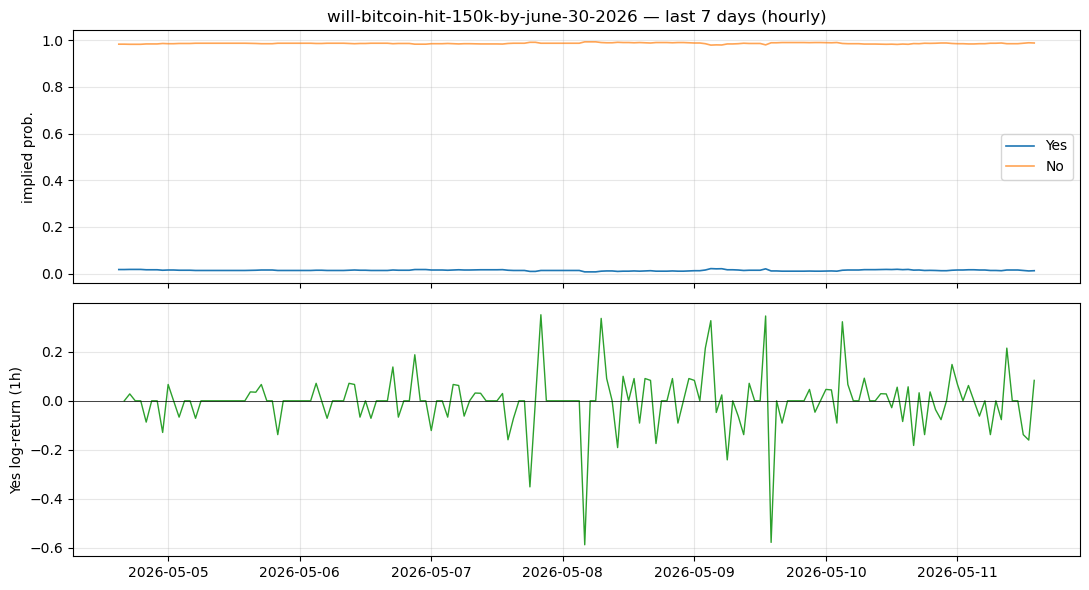

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(prices.index, prices["yes"], label="Yes", linewidth=1.2)
axes[0].plot(prices.index, prices["no"],  label="No",  linewidth=1.2, alpha=0.7)
axes[0].set_ylabel("implied prob.")
axes[0].set_title(f"{binary_top['slug']} — last 7 days (hourly)")
axes[0].legend(loc="best"); axes[0].grid(alpha=0.3)

# Hourly log-return on Yes — useful for volatility-based anomaly detection
prices["yes_ret_1h"] = np.log(prices["yes"].replace(0, np.nan)).diff()
axes[1].plot(prices.index, prices["yes_ret_1h"], color="C2", linewidth=1.0)
axes[1].axhline(0, color="k", linewidth=0.5)
axes[1].set_ylabel("Yes log-return (1h)")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. CLOB `/book` — current order book and microstructure metrics

`/book.timestamp` is in **milliseconds** (not seconds). Compute mid, spread,
depth at 1c / 2c / 5c around mid, and book imbalance.

In [13]:
def fetch_book(token_id: str) -> dict:
    b = get_json(f"{CLOB}/book", params={"token_id": token_id})
    # Canonicalise the timestamp (it is in milliseconds)
    b["ts_utc"] = pd.to_datetime(int(b["timestamp"]), unit="ms", utc=True)
    return b

def book_metrics(book: dict) -> dict:
    bids = [(float(x["price"]), float(x["size"])) for x in book.get("bids", [])]
    asks = [(float(x["price"]), float(x["size"])) for x in book.get("asks", [])]
    bb = max(p for p, _ in bids) if bids else None
    ba = min(p for p, _ in asks) if asks else None
    mid = (bb + ba) / 2 if (bb is not None and ba is not None) else None
    out = {
        "token_id": book["asset_id"],
        "ts_utc": book["ts_utc"],
        "best_bid": bb, "best_ask": ba, "mid": mid,
        "spread": (ba - bb) if (bb is not None and ba is not None) else None,
        "tick_size": float(book.get("tick_size", 0)),
        "neg_risk": book.get("neg_risk"),
        "last_trade_price": float(book.get("last_trade_price", 0) or 0),
        "n_bid_levels": len(bids),
        "n_ask_levels": len(asks),
    }
    if mid is not None:
        for w_cents in (1, 2, 5):
            w = w_cents / 100
            bd = sum(s for p, s in bids if mid - p <= w)
            ad = sum(s for p, s in asks if p - mid <= w)
            out[f"bid_depth_{w_cents}c"] = bd
            out[f"ask_depth_{w_cents}c"] = ad
            denom = bd + ad
            out[f"imbalance_{w_cents}c"] = (bd - ad) / denom if denom > 0 else None
    return out

yes_book = fetch_book(YES)
no_book  = fetch_book(NO)
mets = pd.DataFrame([book_metrics(yes_book), book_metrics(no_book)],
                    index=["Yes", "No"])
mets.T


,Yes,No
token_id,1391568931726907821916849673900873751774056619...,1329064291452118987160211966345205412635984290...
ts_utc,2026-05-11 14:12:21.605000+00:00,2026-05-11 14:12:21.605000+00:00
best_bid,0.012,0.987
best_ask,0.013,0.988
mid,0.0125,0.9875
spread,0.001,0.001
tick_size,0.001,0.001
neg_risk,False,False
last_trade_price,0.014,0.014
n_bid_levels,12,59


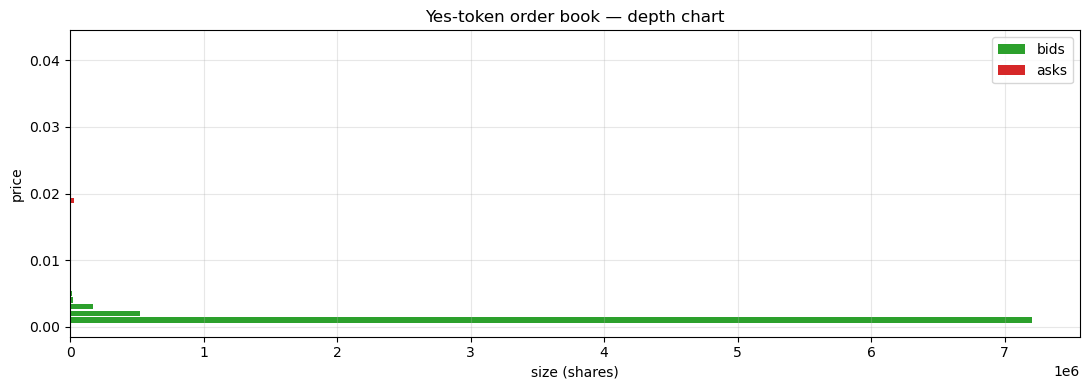

In [14]:
# Plot the top of book — depth-by-level chart
def book_depth_frame(book: dict, side: str, levels: int = 20) -> pd.DataFrame:
    data = book.get(side, [])
    rows = [(float(x["price"]), float(x["size"])) for x in data]
    rows.sort(key=lambda r: r[0], reverse=(side == "bids"))
    return pd.DataFrame(rows[:levels], columns=["price", "size"])

bids_df = book_depth_frame(yes_book, "bids", levels=15)
asks_df = book_depth_frame(yes_book, "asks", levels=15)

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(bids_df["price"], bids_df["size"], color="C2", height=0.0008, label="bids")
ax.barh(asks_df["price"], asks_df["size"], color="C3", height=0.0008, label="asks")
ax.set_xlabel("size (shares)")
ax.set_ylabel("price")
ax.set_title(f"Yes-token order book — depth chart")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Data API `/trades` — wallet-level activity, signed pressure, whale concentration

We pull up to 2,000 recent trades on the chosen market, sign the flow into
*Yes-pressure*, and look for windows of high whale concentration.

For a binary YES/NO market:

```
signed_yes_pressure =
  +size*price   if BUY  Yes
  -size*price   if SELL Yes
  -size*price   if BUY  No
  +size*price   if SELL No
```

In [15]:
def page_trades(condition_id: str, max_records: int = 2000,
                min_notional_cash: float | None = None,
                page_size: int = 500) -> pd.DataFrame:
    rows: list[dict] = []
    offset = 0
    while len(rows) < max_records:
        params = {"market": condition_id, "limit": page_size,
                  "offset": offset, "takerOnly": "false"}
        if min_notional_cash is not None:
            params["filterType"] = "CASH"
            params["filterAmount"] = min_notional_cash
        batch = get_json(f"{DATA}/trades", params=params)
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["ts_utc"] = pd.to_datetime(df["timestamp"].astype(int), unit="s", utc=True)
    df["size"] = df["size"].astype(float)
    df["price"] = df["price"].astype(float)
    df["notional"] = df["size"] * df["price"]
    return df


In [16]:
# Grab the condition id of the chosen market
binary_top_raw = next(m for m in markets_raw if m["id"] == binary_top["id"])
binary_top_raw_cid = binary_top_raw["conditionId"]
print(f"conditionId = {binary_top_raw_cid}")
trades = page_trades(binary_top_raw_cid, max_records=2000)
print(f"pulled {len(trades)} trades from {trades['ts_utc'].min()} to {trades['ts_utc'].max()}")
print(f"distinct wallets: {trades['proxyWallet'].nunique()}")
trades[["ts_utc","proxyWallet","side","outcome","size","price","notional"]].head()


conditionId = 0xa0f4c4924ea1a8b410b4ce821c2a9955fad21a1b19bdcfde90816732278b3dd5


pulled 2000 trades from 2026-05-08 12:36:26+00:00 to 2026-05-11 14:08:24+00:00
distinct wallets: 312


,ts_utc,proxyWallet,side,outcome,size,price,notional
0,2026-05-11 14:08:24+00:00,0xee0db4dd04ed7a085c62ca13ad6f85b10bb50404,BUY,Yes,212.76,0.013138,2.79529
1,2026-05-11 14:08:24+00:00,0x0595eafcd68be6c10fe4fbde5c6d0031dee449d4,SELL,Yes,91.02,0.014000,1.27428
2,2026-05-11 14:08:24+00:00,0x238fe1b4a91d47bda4fb418dd4a6a09494983015,SELL,Yes,42.93,0.013000,0.55809
3,2026-05-11 14:08:24+00:00,0x3e6aee1898c37494b2cdb06da1f43c10b16ae86d,SELL,Yes,17.20,0.013000,0.22360
4,2026-05-11 14:08:24+00:00,0xc81d240a30af4ddcd0db5d21b6ed15081e24bc5d,BUY,No,61.61,0.988000,60.87068


In [17]:
def sign_yes(row) -> float:
    s, p = row["size"], row["price"]
    is_buy = row["side"] == "BUY"
    if row["outcome"] == "Yes":
        return  s * p if is_buy else -s * p
    else:
        return -s * p if is_buy else  s * p

trades["signed_yes_pressure"] = trades.apply(sign_yes, axis=1)
total_notional = trades["notional"].sum()
net_pressure  = trades["signed_yes_pressure"].sum()
print(f"total notional in window: ${total_notional:,.0f}")
print(f"net signed Yes pressure:   ${net_pressure:,.0f}")
print(f"  (positive = net BUY-Yes  /  negative = net BUY-No)")


total notional in window: $70,359
net signed Yes pressure:   $-25,345
  (positive = net BUY-Yes  /  negative = net BUY-No)


In [18]:
# Wallet leaderboard for this market
by_wallet = (
    trades
    .groupby("proxyWallet")
    .agg(n_trades=("price", "count"),
         notional=("notional", "sum"),
         net_yes_pressure=("signed_yes_pressure", "sum"),
         first_ts=("ts_utc", "min"),
         last_ts=("ts_utc", "max"))
    .sort_values("notional", ascending=False)
)
by_wallet["notional_share"] = by_wallet["notional"] / by_wallet["notional"].sum()
top = by_wallet.head(10)
print(f"top-10 wallets account for {top['notional_share'].sum():.0%} of notional")
top


top-10 wallets account for 62% of notional


,n_trades,notional,net_yes_pressure,first_ts,last_ts,notional_share
proxyWallet,,,,,,
0xfea31bc088000ff909be1dfd8d0e3f2c7ef2d227,40,18308.779521,-18308.779521,2026-05-08 23:02:15+00:00,2026-05-11 00:11:40+00:00,0.260218
0x2e4818113b183641c2b3f25ca6b4c962c57a95c7,14,6412.662239,-479.756747,2026-05-10 03:43:26+00:00,2026-05-11 09:48:09+00:00,0.091142
0x0628e9c41831d66c695f8ed62a901ee0d24dbcd8,81,4501.152952,422.472856,2026-05-08 12:37:22+00:00,2026-05-11 13:52:44+00:00,0.063974
0x8cb3847851a810eea254cdf97530959f0925b8ed,76,3318.770769,29.320463,2026-05-08 12:37:22+00:00,2026-05-11 13:20:11+00:00,0.047169
0x3b5c7896c181642a2edd8617daecda98a50a39a6,1,3055.000000,-3055.000000,2026-05-11 05:42:16+00:00,2026-05-11 05:42:16+00:00,0.043420
0xad6092f0ab7cda2a84977d18cabecbdbe4e397f4,10,2074.461894,-1282.538106,2026-05-09 12:14:42+00:00,2026-05-10 02:07:51+00:00,0.029484
0x3e6aee1898c37494b2cdb06da1f43c10b16ae86d,317,1773.474829,-16.286337,2026-05-08 12:37:22+00:00,2026-05-11 14:08:24+00:00,0.025206
0x899843e09e4faaafc65682535cb1fd8ad2f032be,5,1587.686506,1587.686506,2026-05-10 02:19:26+00:00,2026-05-10 03:43:26+00:00,0.022565
0xdc62ee4f66555520c58230d6ae8a9d10a5bf1eb3,34,1520.052937,50.777379,2026-05-08 13:21:49+00:00,2026-05-11 10:30:09+00:00,0.021604


In [19]:
# 5-minute whale-concentration windows
trades_idx = trades.set_index("ts_utc").sort_index()
buckets = (
    trades_idx
    .assign(bucket=lambda d: d.index.floor("5min"))
    .groupby(["bucket", "proxyWallet"])["notional"].sum()
    .reset_index()
)
bucket_totals = buckets.groupby("bucket")["notional"].sum().rename("bucket_total")
buckets = buckets.merge(bucket_totals, on="bucket")
buckets["wallet_share"] = buckets["notional"] / buckets["bucket_total"]
hot = (
    buckets[buckets["bucket_total"] > 1000]   # ignore micro-buckets
    .sort_values("wallet_share", ascending=False)
    .head(10)
)
print("5-min windows with the highest single-wallet dominance "
      "(bucket notional > $1000):")
hot


5-min windows with the highest single-wallet dominance (bucket notional > $1000):


,bucket,proxyWallet,notional,bucket_total,wallet_share
224,2026-05-08 23:05:00+00:00,0xfea31bc088000ff909be1dfd8d0e3f2c7ef2d227,6236.311255,6436.549284,0.968890
681,2026-05-10 03:45:00+00:00,0x2e4818113b183641c2b3f25ca6b4c962c57a95c7,2554.814200,2813.520000,0.908049
220,2026-05-08 23:00:00+00:00,0xfea31bc088000ff909be1dfd8d0e3f2c7ef2d227,2637.575354,3009.729314,0.876350
256,2026-05-09 00:25:00+00:00,0xfea31bc088000ff909be1dfd8d0e3f2c7ef2d227,3289.404460,3820.053740,0.861089
1088,2026-05-11 05:40:00+00:00,0x3b5c7896c181642a2edd8617daecda98a50a39a6,3055.000000,4855.418000,0.629194
408,2026-05-09 12:10:00+00:00,0xad6092f0ab7cda2a84977d18cabecbdbe4e397f4,689.500000,1113.762941,0.619072
667,2026-05-10 02:30:00+00:00,0x899843e09e4faaafc65682535cb1fd8ad2f032be,509.999996,1019.999992,0.500000
666,2026-05-10 02:30:00+00:00,0x30ddc624503628845ece743b280b291feb61bb80,499.999998,1019.999992,0.490196
646,2026-05-10 02:05:00+00:00,0xad6092f0ab7cda2a84977d18cabecbdbe4e397f4,748.722450,1684.855700,0.444384
645,2026-05-10 02:05:00+00:00,0x8a63484af5c8d284106eac7f3688ba9e818210b3,720.123560,1684.855700,0.427410


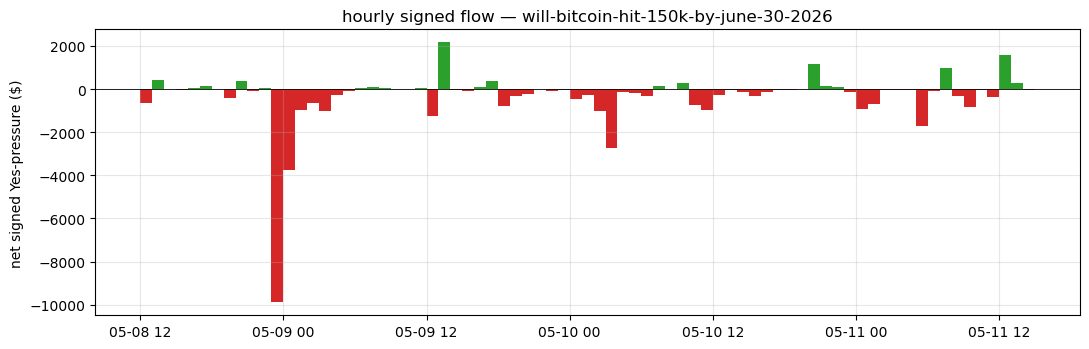

In [20]:
# Visualise hourly net signed pressure
fig, ax = plt.subplots(figsize=(11, 3.6))
hourly = trades.set_index("ts_utc")["signed_yes_pressure"].resample("1h").sum()
colors = ["C2" if v >= 0 else "C3" for v in hourly.values]
ax.bar(hourly.index, hourly.values, width=pd.Timedelta(hours=1), color=colors,
       align="edge")
ax.axhline(0, color="k", linewidth=0.6)
ax.set_ylabel("net signed Yes-pressure ($)")
ax.set_title(f"hourly signed flow — {binary_top['slug']}")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Data API `/holders` — concentration of positions

`/holders` returns a list **per token**, each with its own `holders[]`. To get
both outcomes you must call once per token id and concatenate. The response is
also capped (typically 100 per token), so it is a *Top-N* view, not a complete
holder distribution.

In [21]:
def fetch_holders(condition_id: str, limit: int = 50, min_balance: int = 1) -> pd.DataFrame:
    """Note: /holders takes a conditionId (NOT a token id) and returns
    a list of objects, one per outcome token. minBalance must be int."""
    payload = get_json(f"{DATA}/holders",
                       params={"market": condition_id, "limit": limit,
                               "minBalance": int(min_balance)})
    rows = []
    for entry in payload:
        token = entry["token"]
        for h in entry.get("holders", []):
            rows.append({
                "token_id": token,
                "proxy_wallet": h.get("proxyWallet"),
                "amount": h.get("amount"),
                "outcome_index": h.get("outcomeIndex"),
                "name": h.get("name"),
                "pseudonym": h.get("pseudonym"),
                "verified": h.get("verified"),
            })
    return pd.DataFrame(rows)

holders = fetch_holders(binary_top_raw_cid, limit=50)
holders["outcome"] = holders["token_id"].map(
    {YES: "Yes", NO: "No"}
)
print(f"distinct outcome tokens returned: {holders['token_id'].nunique()}")
print(f"rows: {len(holders)}  (Yes={len(holders[holders['outcome']=='Yes'])}, "
      f"No={len(holders[holders['outcome']=='No'])})")

# Top-N concentration per outcome
def concentration(df: pd.DataFrame, top_n: int = 5) -> dict:
    if df.empty:
        return {}
    df = df.sort_values("amount", ascending=False)
    total_amount = df["amount"].sum()
    return {
        "top1_share": df.iloc[0]["amount"] / total_amount,
        f"top{top_n}_share": df.head(top_n)["amount"].sum() / total_amount,
        "n_holders_returned": len(df),
        "total_amount": total_amount,
    }

for outcome, sub in holders.groupby("outcome"):
    print(f"{outcome:>4} outcome concentration: {concentration(sub)}")


distinct outcome tokens returned: 2
rows: 100  (Yes=50, No=50)
  No outcome concentration: {'top1_share': 0.42727781737011866, 'top5_share': 0.6056647262723255, 'n_holders_returned': 50, 'total_amount': 286100.05357499997}
 Yes outcome concentration: {'top1_share': 0.09725433536101591, 'top5_share': 0.3816849878230958, 'n_holders_returned': 50, 'total_amount': 233044.93513700002}


## 7. Putting it together — a toy suspicion score

Combine three of the v2 microstructure features into a single per-5-minute-window
score, just to demonstrate the shape. **Not** a production score:

- `whale_concentration_z` — max single-wallet share in the bucket, z-scored.
- `abs_return_z` — absolute hourly Yes return mapped onto the bucket.
- `bucket_notional_z` — total bucket notional, z-scored.

Then we threshold and inspect the top suspicious buckets.

In [22]:
# Per 5-min bucket features
trades_idx = trades.set_index("ts_utc").sort_index()
bucket_size = "5min"

bucket_total = trades_idx["notional"].resample(bucket_size).sum().rename("bucket_total")

# Max wallet share per bucket
def _max_share(grp: pd.DataFrame) -> float:
    total = grp["notional"].sum()
    if total <= 0:
        return np.nan
    return grp.groupby("proxyWallet")["notional"].sum().max() / total

max_share = (
    trades_idx
    .groupby(pd.Grouper(freq=bucket_size))
    .apply(_max_share, include_groups=False)
    .rename("max_wallet_share")
)

# Absolute return per bucket from the hourly price series (forward-filled then resampled)
prices_5m = prices["yes"].resample("5min").ffill()
ret_5m = prices_5m.pct_change().abs().rename("abs_return_5m")

feat = pd.concat([bucket_total, max_share, ret_5m], axis=1).dropna(how="all")
# z-score each column, ignoring NaNs
for col in ["bucket_total", "max_wallet_share", "abs_return_5m"]:
    mu, sigma = feat[col].mean(), feat[col].std(ddof=0)
    feat[f"{col}_z"] = (feat[col] - mu) / (sigma if sigma else 1.0)

feat["suspicion_toy"] = (
    0.4 * feat["max_wallet_share_z"].fillna(0) +
    0.3 * feat["abs_return_5m_z"].fillna(0) +
    0.3 * feat["bucket_total_z"].fillna(0)
)
feat.sort_values("suspicion_toy", ascending=False).head(10)


,bucket_total,max_wallet_share,abs_return_5m,bucket_total_z,max_wallet_share_z,abs_return_5m_z,suspicion_toy
2026-05-08 23:05:00+00:00,6436.549284,0.968890,0.000000,17.053427,1.295584,-0.156662,5.587263
2026-05-09 14:00:00+00:00,1.011090,0.989000,0.439024,-0.211049,1.382232,13.753542,4.615641
2026-05-08 04:00:00+00:00,NaN,NaN,0.444444,NaN,NaN,13.925273,4.177582
2026-05-07 20:00:00+00:00,NaN,NaN,0.421053,NaN,NaN,13.184118,3.955235
2026-05-09 13:00:00+00:00,0.000000,NaN,0.413793,-0.213761,NaN,12.954105,3.822103
2026-05-08 07:00:00+00:00,NaN,NaN,0.400000,NaN,NaN,12.517079,3.755124
2026-05-11 05:40:00+00:00,4855.418000,0.629194,0.000000,12.811761,-0.168112,-0.156662,3.729285
2026-05-08 23:00:00+00:00,3009.729314,0.876350,0.095238,7.860373,0.896841,2.860895,3.575117
2026-05-09 03:00:00+00:00,0.000000,NaN,0.387097,-0.213761,NaN,12.108249,3.568346
2026-05-10 03:00:00+00:00,0.000000,NaN,0.380952,-0.213761,NaN,11.913568,3.509942


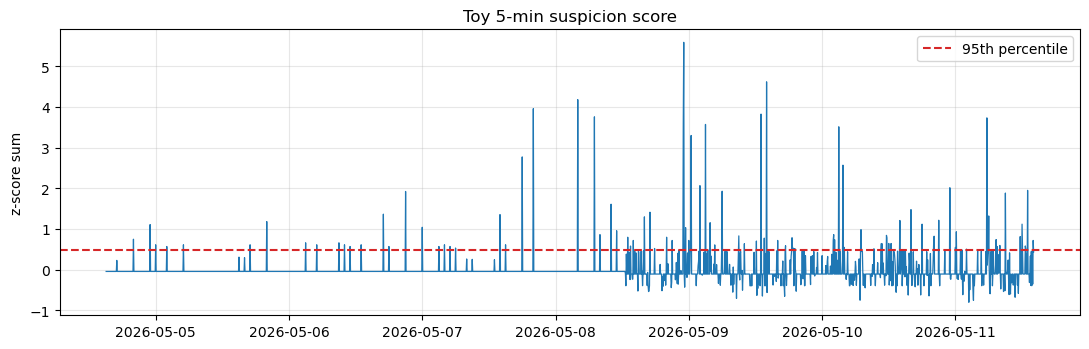

In [23]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(feat.index, feat["suspicion_toy"], linewidth=0.9)
ax.axhline(feat["suspicion_toy"].quantile(0.95), color="C3", linestyle="--",
           label="95th percentile")
ax.set_title("Toy 5-min suspicion score")
ax.set_ylabel("z-score sum")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Summary — what we got, what we did NOT get

### What the free APIs gave us, validated above

| Need | Endpoint | Status |
|---|---|---|
| Market metadata + ~60 pre-computed fields | Gamma `/markets` | ✅ |
| negRisk family enumeration | Gamma `/events/{id}.markets` | ✅ (note: not via `negRiskRequestID`) |
| Per-outcome historical probability | CLOB `/prices-history` | ✅ (needs resample to align Yes/No) |
| Current full L2 order book | CLOB `/book` | ✅ (timestamp is **ms**, not s) |
| Wallet-level trade tape | Data API `/trades` | ✅ (paginate; supports `filterType=CASH` for whale filter) |
| Top holders per outcome | Data API `/holders` | ✅ (per-token, capped; not a full distribution) |
| Signed flow / whale concentration / 5-min anomaly bucketing | Derived | ✅ |

### What we did NOT get from the free APIs

- **Historical L2 depth beyond what we collect ourselves or via PMXT.** `/book` is a current snapshot. For backtesting microstructure anomalies, run the WebSocket collector going forward and ingest PMXT for the past.
- **Maker / taker counterparty attribution.** Without it, wash-trade graphs are approximated using same-tx, rapid round-trip, and shared-funding heuristics.
- **Order placement / cancellation events.** Spoofing remains a *book-instability proxy*, not proof.
- **Direct negRisk-conversion events.** Conversions happen on-chain via the CTF gadget; we need a Polygon subgraph (Goldsky / The Graph / Bitquery) to observe them as ERC-1155 transfers.
- **UMA dispute history.** Same — needs an on-chain indexer.
- **Closed/archived markets older than the API retention window.** Some historical data is only reachable via on-chain replay.

### Next steps (mapped to v2 spec phases)

1. **Phase 1 finishing touches** — wrap the loaders here into a `polymarket_loader/` module, write Parquet outputs, add data-quality assertions.
2. **Phase 3 in parallel** — wire a Goldsky / Bitquery subgraph for ERC-1155 + UMA disputes; reconcile against `/trades`.
3. **Phase 2** — implement the Saguillo-style combinatorial arbitrage detector over the full negRisk family pulled in section 2.
4. **Phase 4** — replace the polling here with the WebSocket market channel (`wss://ws-subscriptions-clob.polymarket.com/ws/market`) and persist raw events.